## Outlier detection

Next we'll be using [this](https://www.kaggle.com/competitions/ventilator-pressure-prediction/data) dataset. A modified zip-file is also stored in files as "ventilator-pressure-prediction-train.zip". Let's start by reading the [zipped csv as a pandas dataframe](https://www.geeksforgeeks.org/read-a-zipped-file-as-a-pandas-dataframe/).

(The modifications: the zip-files you get from kaggle contains 3 files, but this zip-file only contains 1. That makes it possible to immediatly load it using pd.to_csv. Our csv also only contains the first 1010 rows where the original contains a lot more.)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("files/ventilator-pressure-prediction-train.zip")
df.head()

,id,breath_id,R,C,time_step,u_in,u_out,pressure
0,1,1,20,50,0.000000,0.083334,0,5.837492
1,2,1,20,50,0.033652,18.383041,0,5.907794
2,3,1,20,50,0.067514,22.509278,0,7.876254
3,4,1,20,50,0.101542,22.808822,0,11.742872
4,5,1,20,50,0.135756,25.355850,0,12.234987


* Set the first 1000 samples(rows) of "train.csv" in a df_part dataframe
* Plot the scatter plot with x='breath_id',y='pressure'

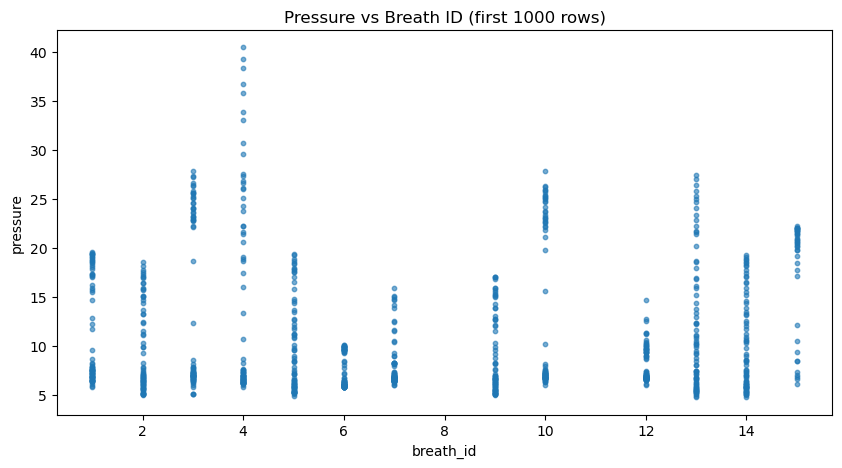

In [3]:
# Part 2: first 1000 rows + scatter plot

df_part = df.iloc[:1000].copy()
plt.figure(figsize=(10, 5))
plt.scatter(df_part['breath_id'], df_part['pressure'], s=10, alpha=0.6)
plt.title('Pressure vs Breath ID (first 1000 rows)')
plt.xlabel('breath_id')
plt.ylabel('pressure')
plt.show()

* Plot the 'pressure' column of df_part using boxplot. 

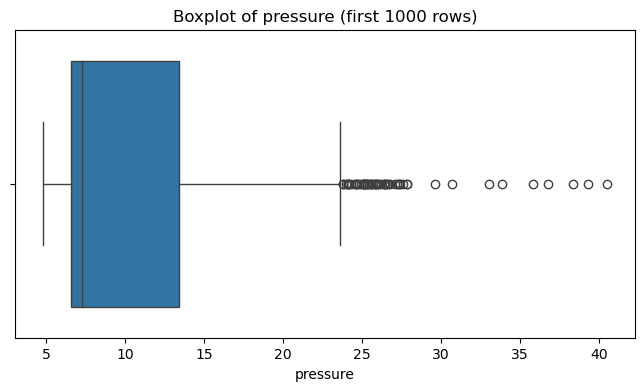

In [6]:
# Part 3: boxplot of pressure
import seaborn as sns
plt.figure(figsize=(8,4))
sns.boxplot(x=df_part['pressure'])
plt.title('Boxplot of pressure (first 1000 rows)')
plt.xlabel('pressure')
plt.show()

This dataset is clearly skewed. Explain:

* how we can see this using the above boxplot
* what it means

(No code in the following code block, just text.)

In [7]:
# Explanation (text only)
print('The boxplot shows a long upper whisker and many points above it, indicating positive skew. It means the distribution has a tail to the right with high pressure values as outliers.')

The boxplot shows a long upper whisker and many points above it, indicating positive skew. It means the distribution has a tail to the right with high pressure values as outliers.


* Calculate the 25th, 50th and 75th percentile of this data. 
* Explain what these numbers mean.

(Some code and some text in the following block).

In [8]:
# Part 4: percentiles
q25 = df_part['pressure'].quantile(0.25)
q50 = df_part['pressure'].quantile(0.50)
q75 = df_part['pressure'].quantile(0.75)
print('25th percentile:', q25)
print('50th percentile (median):', q50)
print('75th percentile:', q75)
print('\nThese values divide the pressure distribution into quartiles: 25%, 50%, 75% of data is below these points.')

25th percentile: 6.52293762321848
50th percentile (median): 7.243534614093444
75th percentile: 13.37739680471206

These values divide the pressure distribution into quartiles: 25%, 50%, 75% of data is below these points.


* Calculate standard deviation of the pressure data. Show this number.

In [9]:
# Part 5: standard deviation
std_pressure = df_part['pressure'].std()
print('Standard deviation of pressure:', std_pressure)

Standard deviation of pressure: 6.369345479643049


Use the standard deviation to calculate the number of outliers.
Multiple the standard deviation by 2. Count the number of values in the pressure column that are:

* Smaller than the **median - 2 * stddev**
* Bigger than the **median + 2 * stddev**

This way you get a clear overview of the number of outliers. Compare your numbers with the outliers displayed in the boxplot (0 outliers below, 118 outliers above)

In [10]:
# Part 6: outliers via 2*std from median
median_pressure = df_part['pressure'].median()
lower_bound = median_pressure - 2 * std_pressure
upper_bound = median_pressure + 2 * std_pressure

outliers_low = df_part[df_part['pressure'] < lower_bound]
outliers_high = df_part[df_part['pressure'] > upper_bound]

print('Median:', median_pressure)
print('lower bound:', lower_bound)
print('upper bound:', upper_bound)
print('outliers below:', len(outliers_low))
print('outliers above:', len(outliers_high))
print('total outliers:', len(outliers_low)+len(outliers_high))

Median: 7.243534614093444
lower bound: -5.495156345192654
upper bound: 19.98222557337954
outliers below: 0
outliers above: 118
total outliers: 118
